### A ride-sharing company operates thousands of taxi rides every day in New York City.

- Problems they face:
    - Pickup locations are not categorized
    - Some areas are very crowded, some are rarely used
    - GPS data contains noise (random, one-time pickups)
    - Demand hotspots change dynamically

- The company wants to:
    - Discover natural pickup hotspots
    - Ignore random or rare pickup points
    - Understand high-density demand zones
    - Improve:
        - Driver allocation
        - Surge pricing
        - Route planning

They hire you as a Data Scientist to analyze pickup locations and identify natural demand clusters, without knowing how many hotspots exist.

-----------------------------------

1. 1️⃣ Load the Dataset
    - Load the CSV file into a pandas DataFrame.
    - Display the first 5 rows of the dataset.

2. 2️⃣ Feature Selection
    - Extract the following columns:
        - pickup_latitude
        - pickup_longitude
    - Store them in a variable named X.

3. 3️⃣ Data Preprocessing
    -  StandardScaler to scale the selected features.
    - Store the scaled data in X_scaled.

4. 4️⃣ DBSCAN Model – Experiment 1
    - Apply DBSCAN with:
        - eps = 0.2
        - min_samples = 5
    - Store cluster labels in labels_1.

5. 5️⃣ DBSCAN Model – Experiment 2
    - Apply DBSCAN with:
        - eps = 0.3
        - min_samples = 5
    - Store cluster labels in labels_2.

6. 6️⃣ DBSCAN Model – Experiment 3
    - Apply DBSCAN with:
        - eps = 0.5
        - min_samples = 5
    - Store cluster labels in labels_3.

7. 7️⃣ Cluster Evaluation
    - For each experiment:
        Print:
        - Number of clusters (excluding noise)
        - Number of noise points
        - Noise ratio

8. 8️⃣ Silhouette Score Calculation
    - Remove noise points (-1) from each experiment.
    - Calculate and print the Silhouette Score for:
        - Experiment 1
        - Experiment 2
        - Experiment 3
    - If silhouette score is not applicable, print "Not Applicable".

9. 9️⃣ Visualization
    - For each experiment:
        - Plot pickup locations using a scatter plot.
        - Color points based on cluster labels.
        - Highlight noise points using a separate color.
        
10. 🔟 Best Model Selection
    - Based on:
        - Number of clusters
        - Noise ratio
        - Silhouette score
    - Print:
        - Best eps value = ___

In [2]:
import pandas as pd 
import matplotlib.pyplot as plt 
from sklearn.cluster import DBSCAN # DBSCAN clustering algorithm
from sklearn.preprocessing import StandardScaler 

In [3]:
df = pd.read_csv('train.csv')

In [4]:
df.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435


In [5]:
df.isnull().sum()

id                    0
vendor_id             0
pickup_datetime       0
dropoff_datetime      0
passenger_count       0
pickup_longitude      0
pickup_latitude       0
dropoff_longitude     0
dropoff_latitude      0
store_and_fwd_flag    0
trip_duration         0
dtype: int64

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1458644 entries, 0 to 1458643
Data columns (total 11 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   id                  1458644 non-null  object 
 1   vendor_id           1458644 non-null  int64  
 2   pickup_datetime     1458644 non-null  object 
 3   dropoff_datetime    1458644 non-null  object 
 4   passenger_count     1458644 non-null  int64  
 5   pickup_longitude    1458644 non-null  float64
 6   pickup_latitude     1458644 non-null  float64
 7   dropoff_longitude   1458644 non-null  float64
 8   dropoff_latitude    1458644 non-null  float64
 9   store_and_fwd_flag  1458644 non-null  object 
 10  trip_duration       1458644 non-null  int64  
dtypes: float64(4), int64(3), object(4)
memory usage: 122.4+ MB


In [7]:
# 2️ Feature Selection

df_small = df.sample(50000, random_state=42)
X = df_small[['pickup_latitude', 'pickup_longitude']]

print(X.head())

         pickup_latitude  pickup_longitude
67250          40.735943        -73.985611
1397036        40.764351        -73.978394
1021087        40.744389        -73.989059
951424         40.731136        -73.990326
707882         40.646675        -73.789497


In [8]:
# 3️ Data Preprocessing

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(X_scaled[:5])

[[-0.52944667 -0.31428466]
 [ 0.47486178 -0.12970185]
 [-0.23086484 -0.40247856]
 [-0.69937129 -0.43486836]
 [-3.68532448  4.70125566]]


In [9]:
# 4️ DBSCAN Model – Experiment 1

from sklearn.cluster import DBSCAN

dbscan_1 = DBSCAN(eps=0.2, min_samples=5)
labels_1 = dbscan_1.fit_predict(X_scaled)

print(labels_1[:20])

[0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0]


In [10]:
# 5️ DBSCAN Model – Experiment 2

from sklearn.cluster import DBSCAN

dbscan_2 = DBSCAN(eps=0.3, min_samples=5)
labels_2 = dbscan_2.fit_predict(X_scaled)

print(labels_2[:20])

[0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0]


In [11]:
# 6️ DBSCAN Model – Experiment 3

dbscan_3 = DBSCAN(eps=0.5, min_samples=5)
labels_3 = dbscan_3.fit_predict(X_scaled)

print(labels_3[:20])

[0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0]


In [14]:
# 7️ Cluster Evaluation
import numpy as np

experiments = {
    "Experiment 1 (eps=0.2)": labels_1,
    "Experiment 2 (eps=0.3)": labels_2,
    "Experiment 3 (eps=0.5)": labels_3,
}

results = {}

for name, labels in experiments.items():
    num_noise = np.sum(labels == -1)
    num_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise_ratio = num_noise / len(labels)

    print("\n", name)
    print("Number of clusters:", num_clusters)
    print("Number of noise points:", num_noise)
    print("Noise ratio:", noise_ratio)

    results[name] = {
        "clusters": num_clusters,
        "noise_ratio": noise_ratio,
        "silhouette": None
    }



 Experiment 1 (eps=0.2)
Number of clusters: 7
Number of noise points: 121
Noise ratio: 0.00242

 Experiment 2 (eps=0.3)
Number of clusters: 4
Number of noise points: 86
Noise ratio: 0.00172

 Experiment 3 (eps=0.5)
Number of clusters: 3
Number of noise points: 43
Noise ratio: 0.00086


In [15]:
# 8️ Silhouette Score Calculation

from sklearn.metrics import silhouette_score

for name, labels in experiments.items():
    mask = labels != -1

    if len(set(labels[mask])) > 1:
        try:
            score = silhouette_score(X_scaled[mask], labels[mask])
            results[name]["silhouette"] = score
            print(f"{name} Silhouette Score:", score)
        except:
            print(f"{name} Silhouette Score: Not Applicable")
    else:
        print(f"{name} Silhouette Score: Not Applicable")


Experiment 1 (eps=0.2) Silhouette Score: 0.5864071464292029
Experiment 2 (eps=0.3) Silhouette Score: 0.31796231445823026
Experiment 3 (eps=0.5) Silhouette Score: 0.7184702402584741


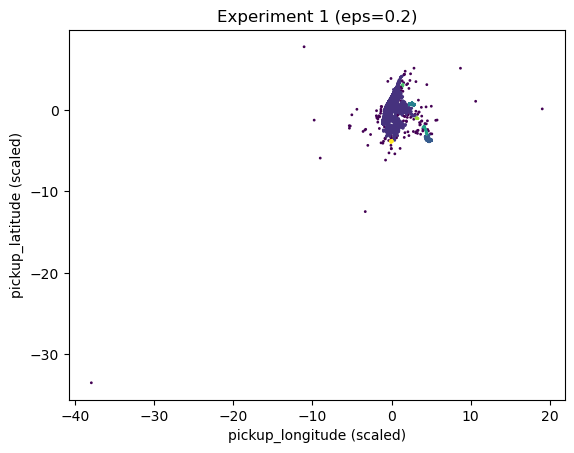

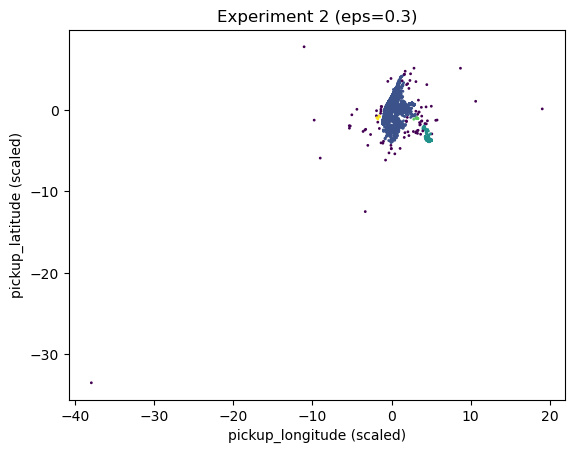

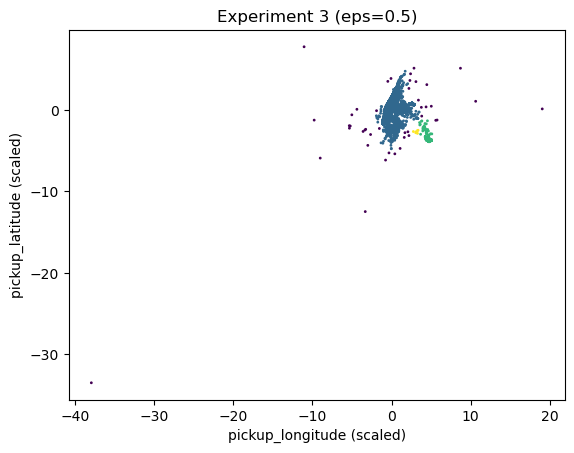

In [16]:
# 9️ Visualization

for name, labels in experiments.items():
    plt.figure()
    plt.scatter(
        X_scaled[:,1],   # longitude
        X_scaled[:,0],   # latitude
        c=labels,
        s=1
    )
    plt.title(name)
    plt.xlabel("pickup_longitude (scaled)")
    plt.ylabel("pickup_latitude (scaled)")
    plt.show()


In [17]:
# 10. Best Model Selection

best_eps = None
best_score = -999

for name, info in results.items():
    sil = info["silhouette"]

    if sil is not None:
        adjusted_score = sil - info["noise_ratio"]

        if adjusted_score > best_score:
            best_score = adjusted_score
            best_eps = name

if best_eps:
    print("Best eps value =", best_eps)
else:
    print("Best eps value = Not Determined")


Best eps value = Experiment 3 (eps=0.5)
